<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/ImproVisAR_keypressheatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

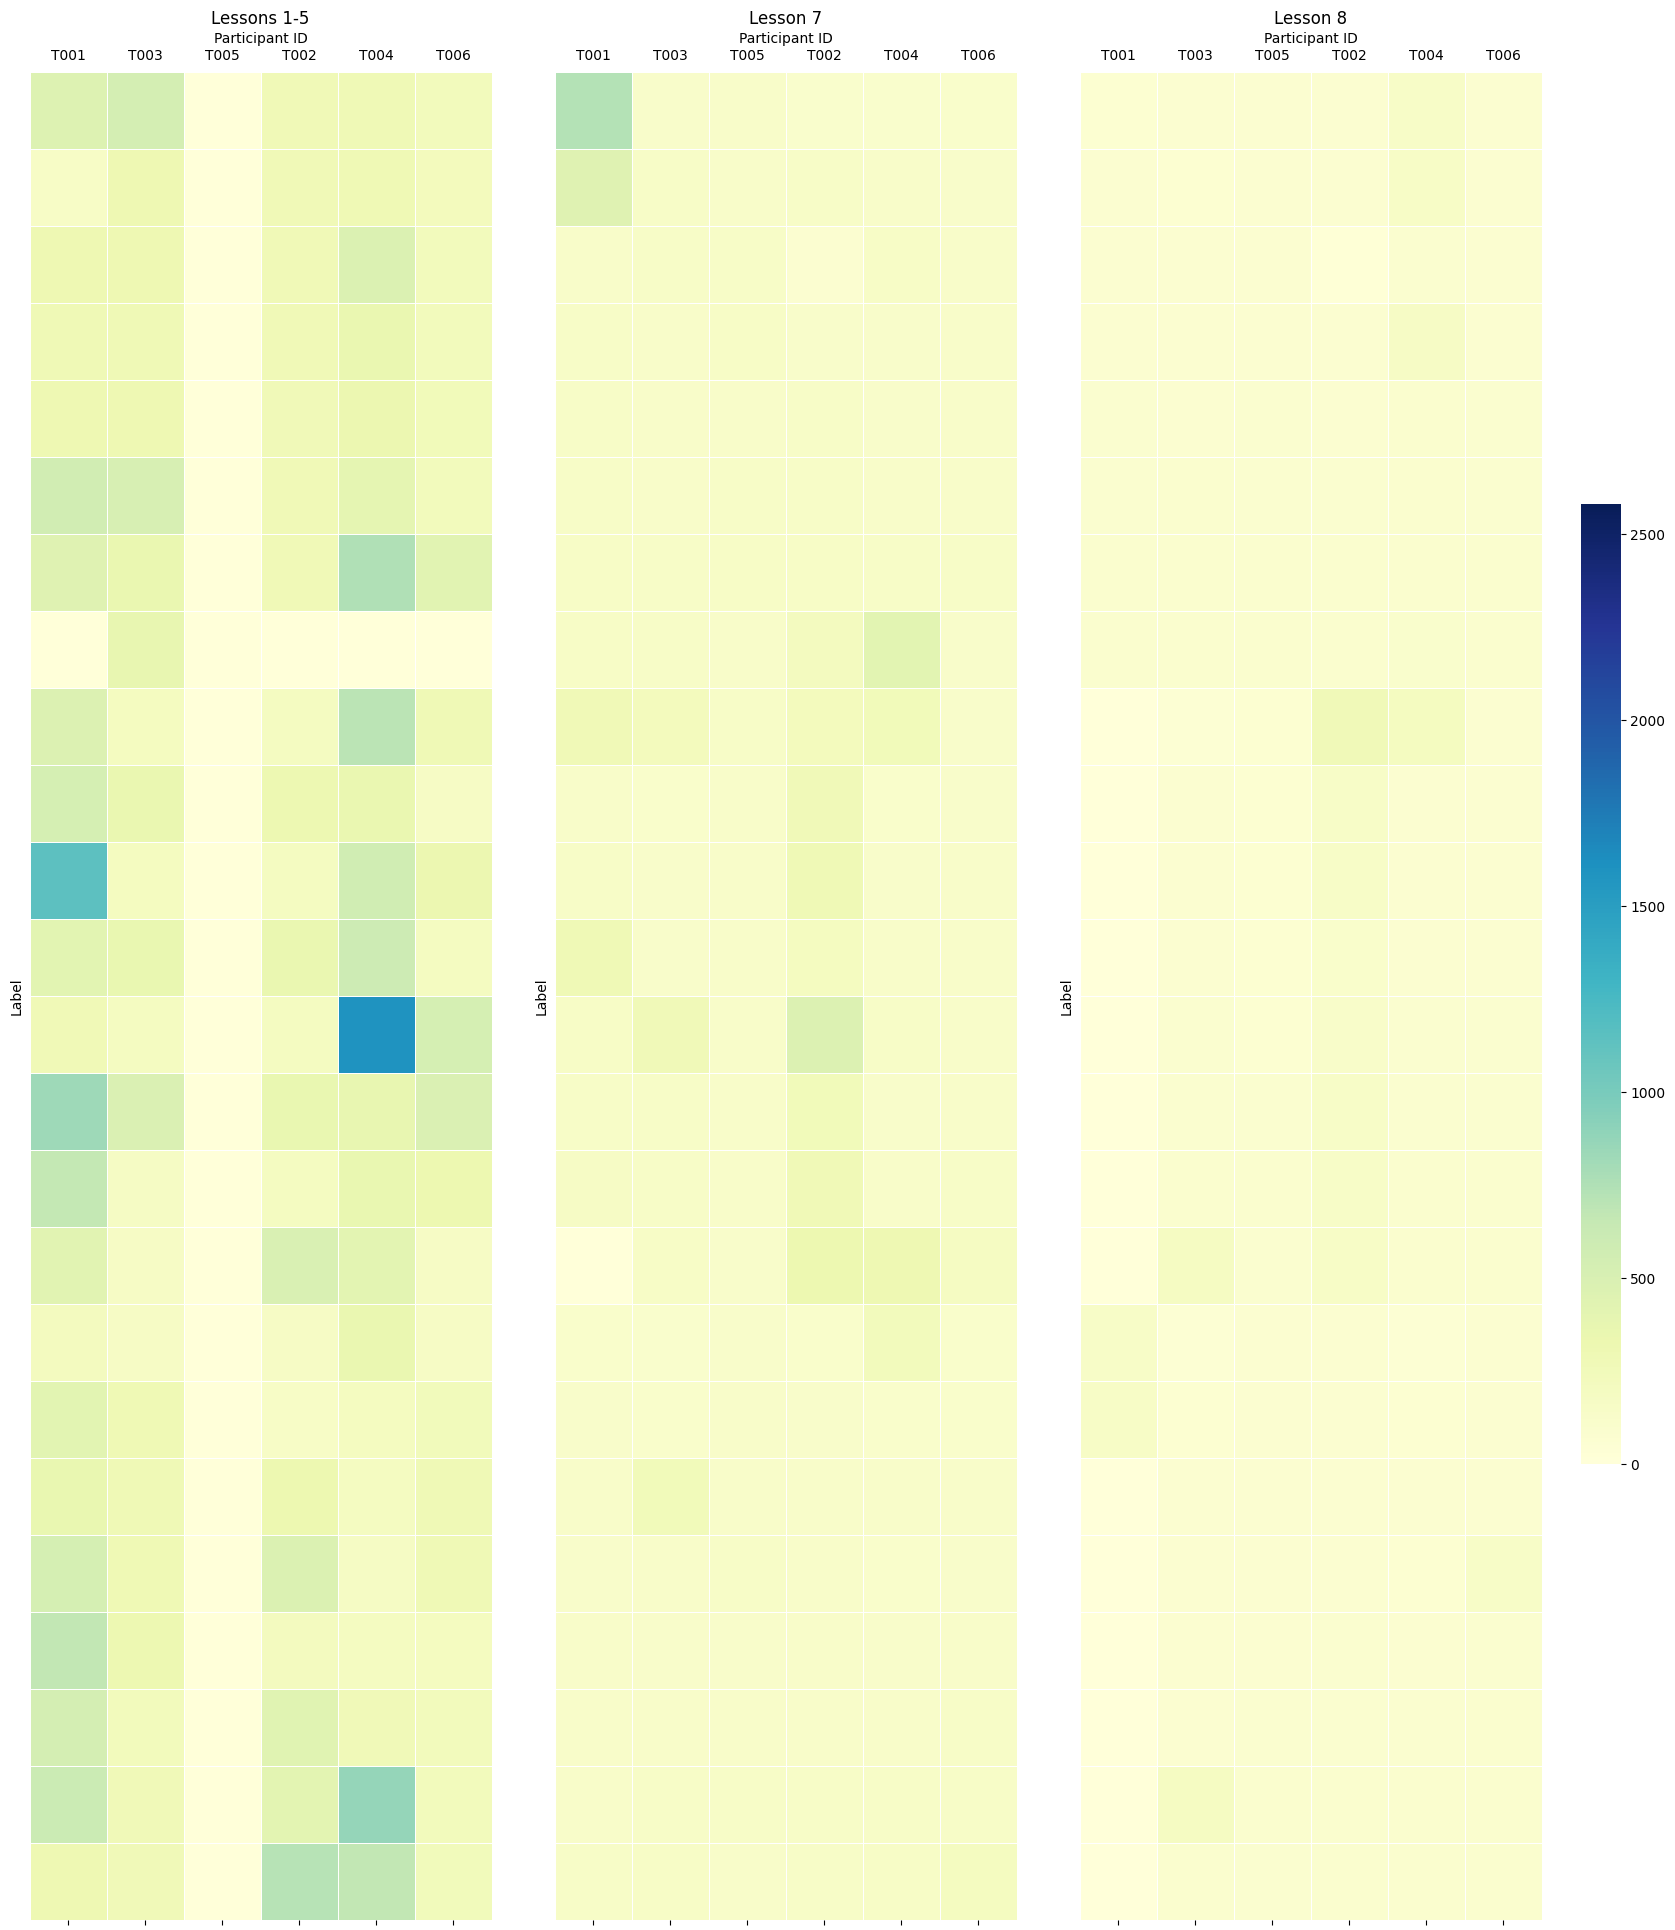

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Define participant sorting: AR = odd IDs, Non-AR = even IDs
participants = sorted(df["ID"].unique(), key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))

# Create simplified task labels
df["Label"] = df.apply(lambda row: f"D{row['Day'][3]}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["Day", "Lesson", "Task"])

# Pivot the data
pivot_df = df.pivot_table(index="Label", columns="ID", values="Keypress_count", aggfunc="sum", fill_value=0)

# Reindex columns based on AR/Non-AR order
pivot_df = pivot_df[participants]

# Create subsets for the three heatmaps using regex patterns safely
heatmap1 = pivot_df[pivot_df.index.to_series().str.contains(r"^D1L[1-5]T")]
heatmap2 = pivot_df[pivot_df.index.to_series().str.contains(r"L7T")]
heatmap3 = pivot_df[pivot_df.index.to_series().str.contains(r"L8T")]

# Determine shared color scale range
vmin = pivot_df.min().min()
vmax = pivot_df.max().max()

# Plot heatmaps side by side with a single colorbar
num_rows = max(len(heatmap1), len(heatmap2), len(heatmap3))
fig, axes = plt.subplots(1, 3, figsize=(20, num_rows), sharey=True)
cbar_ax = fig.add_axes([.91, .3, .02, .4])  # shared colorbar position

for ax in axes:
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', labelbottom=False, labeltop=True, labelrotation=0)

sns.heatmap(heatmap1, cmap="YlGnBu", ax=axes[0], cbar=True, cbar_ax=cbar_ax,
            vmin=vmin, vmax=vmax, xticklabels=True, yticklabels=True, square=True,
            linewidths=0.5, linecolor='white')
axes[0].set_title("Lessons 1-5")
axes[0].set_xlabel("Participant ID")

sns.heatmap(heatmap2, cmap="YlGnBu", ax=axes[1], cbar=False,
            vmin=vmin, vmax=vmax, xticklabels=True, yticklabels=False, square=True,
            linewidths=0.5, linecolor='white')
axes[1].set_title("Lesson 7")
axes[1].set_xlabel("Participant ID")

sns.heatmap(heatmap3, cmap="YlGnBu", ax=axes[2], cbar=False,
            vmin=vmin, vmax=vmax, xticklabels=True, yticklabels=False, square=True,
            linewidths=0.5, linecolor='white')
axes[2].set_title("Lesson 8")
axes[2].set_xlabel("Participant ID")

plt.subplots_adjust(wspace=0.05)
plt.show()


how about we pivot it

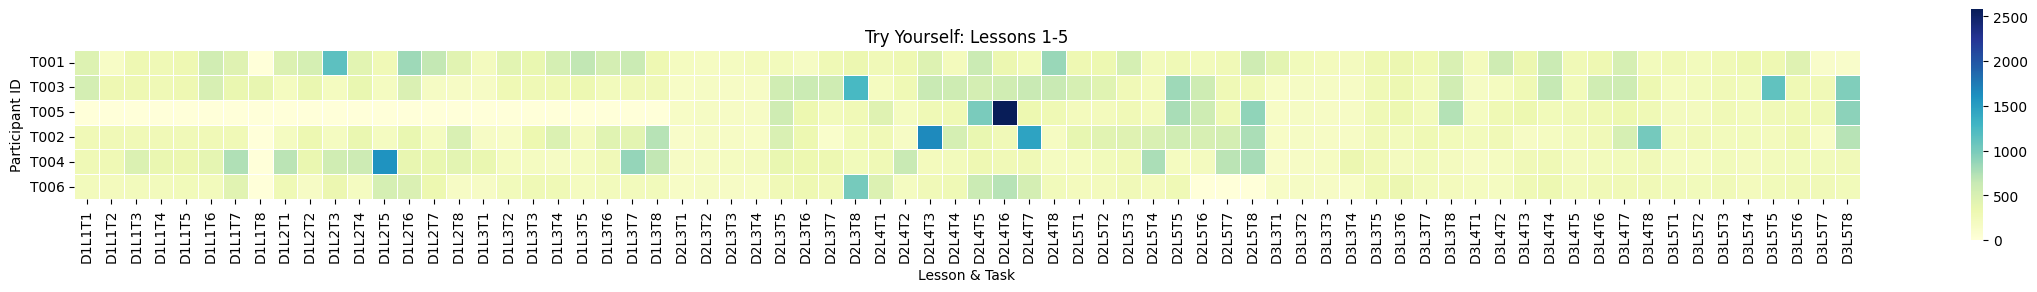

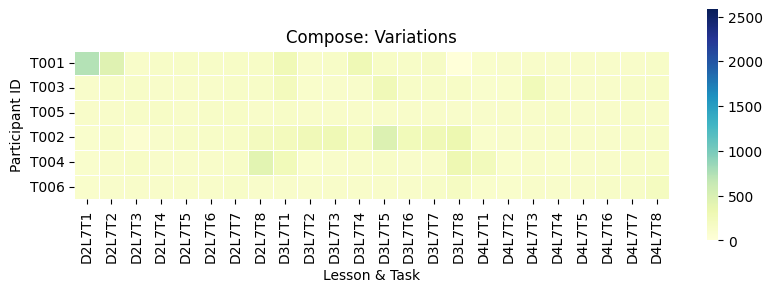

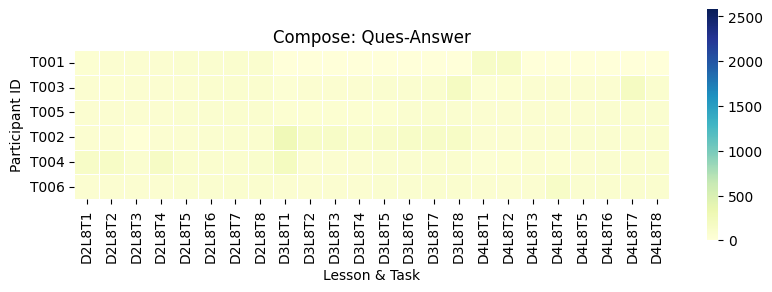

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Define participant sorting: AR = odd IDs, Non-AR = even IDs
participants = sorted(df["ID"].unique(), key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))

# Create simplified task labels
df["Label"] = df.apply(lambda row: f"D{row['Day'][3]}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["Day", "Lesson", "Task"])

# Pivot the full data: Participant IDs as rows, labels as columns
pivot_full = df.pivot_table(index="ID", columns="Label", values="Keypress_count", aggfunc="sum", fill_value=0)

# Reindex rows based on AR/Non-AR order
pivot_full = pivot_full.loc[participants]

# Filter columns for subsets based on full ranges
columns_l1_5 = [col for col in pivot_full.columns if re.match(r"D[1-3]L[1-5]T[1-8]?$", col)]
columns_l7 = [col for col in pivot_full.columns if re.match(r"D[2-4]L7T[1-8]$", col)]
columns_l8 = [col for col in pivot_full.columns if re.match(r"D[2-4]L8T[1-8]$", col)]

# Sort columns
columns_l1_5 = sorted(columns_l1_5)
columns_l7 = sorted(columns_l7)
columns_l8 = sorted(columns_l8)

# Subset data
heatmap1 = pivot_full[columns_l1_5]
heatmap2 = pivot_full[columns_l7]
heatmap3 = pivot_full[columns_l8]

# Determine shared color scale range
vmin = pivot_full.min().min()
vmax = pivot_full.max().max()

# Plot heatmaps with one per figure
figsize1 = (len(heatmap1.columns) * 0.4, len(heatmap1.index) * 0.5)
plt.figure(figsize=figsize1)
sns.heatmap(heatmap1, cmap="YlGnBu", vmin=vmin, vmax=vmax,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Try Yourself: Lessons 1-5")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()

# Use consistent height from first heatmap
height_standard = figsize1[1]

#figsize2 = (len(heatmap2.columns) * 0.4, len(heatmap2.index) * 0.5)
#plt.figure(figsize=figsize2)
figsize2 = (len(heatmap2.columns) * 0.4, height_standard)
plt.figure(figsize=figsize2)
sns.heatmap(heatmap2, cmap="YlGnBu", vmin=vmin, vmax=vmax,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Compose: Variations")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()

#figsize3 = (len(heatmap3.columns) * 0.4, len(heatmap3.index) * 0.5)
#plt.figure(figsize=figsize3)
figsize3 = (len(heatmap3.columns) * 0.4, height_standard)
plt.figure(figsize=figsize3)
sns.heatmap(heatmap3, cmap="YlGnBu", vmin=vmin, vmax=vmax,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Compose: Ques-Answer")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()


good progress. now im gonna add different color bars just to see whats obvious


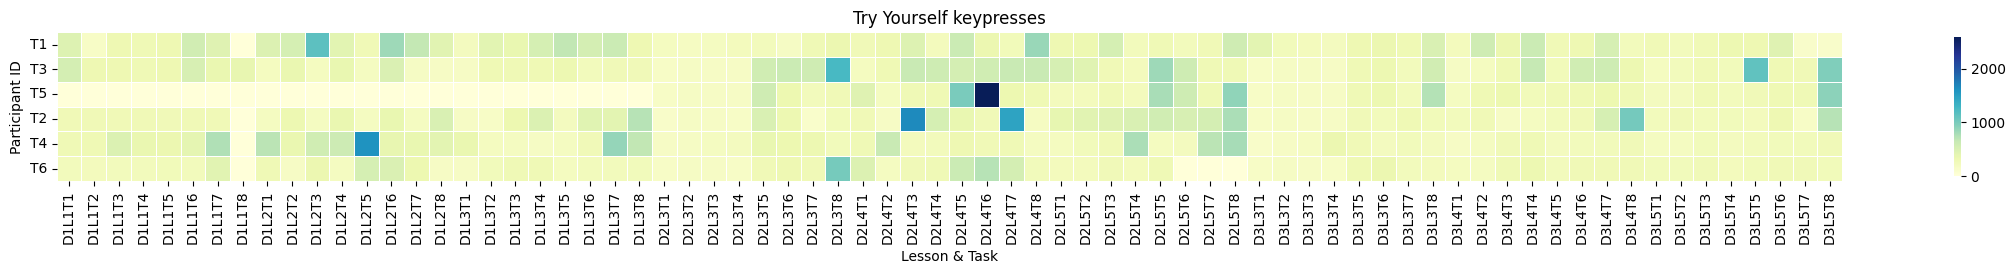

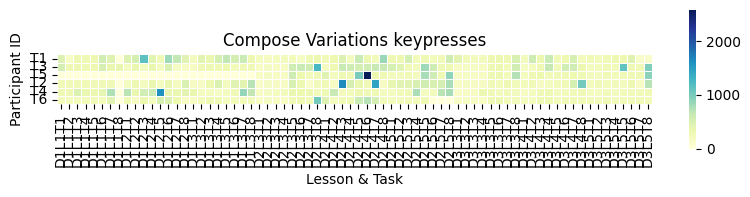

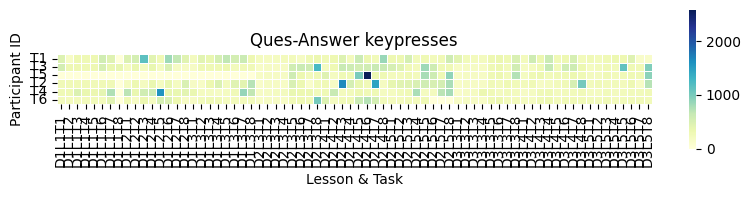

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Define participant sorting: AR = odd IDs, Non-AR = even IDs
participants = sorted(df["ID"].unique(), key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))

# Create simplified task labels
df["Label"] = df.apply(lambda row: f"D{row['Day'][3]}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["Day", "Lesson", "Task"])

# Pivot the full data: Participant IDs as rows, labels as columns
pivot_full = df.pivot_table(index="ID", columns="Label", values="Keypress_count", aggfunc="sum", fill_value=0)

# Reindex rows based on AR/Non-AR order
pivot_full = pivot_full.loc[participants]

# ✅ Rename participant IDs from T001 → T1, T002 → T2, etc.
pivot_full.index = [f"T{int(p[1:])}" for p in pivot_full.index]


# Filter columns for subsets based on full ranges
columns_l1_5 = [col for col in pivot_full.columns if re.match(r"D[1-3]L[1-5]T[1-8]?$", col)]
columns_l7 = [col for col in pivot_full.columns if re.match(r"D[2-4]L7T[1-8]$", col)]
columns_l8 = [col for col in pivot_full.columns if re.match(r"D[2-4]L8T[1-8]$", col)]

# Sort columns
columns_l1_5 = sorted(columns_l1_5)
columns_l7 = sorted(columns_l7)
columns_l8 = sorted(columns_l8)

# Subset data
heatmap1 = pivot_full[columns_l1_5]
heatmap2 = pivot_full[columns_l7]
heatmap3 = pivot_full[columns_l8]

# Plot heatmaps with one per figure and individual colorbars (independent scales)
figsize1 = (len(heatmap1.columns) * 0.4, len(heatmap1.index) * 0.5)
plt.figure(figsize=figsize1)
sns.heatmap(heatmap1, cmap="YlGnBu", cbar_kws={'shrink': 0.6},
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.yticks(rotation=0)
plt.title("Try Yourself keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.savefig("heatmap_lessons1_5.pdf", format="pdf", bbox_inches="tight")
plt.show()

figsize2 = (len(heatmap2.columns) * 0.4, len(heatmap1.index) * 0.5)
plt.figure(figsize=figsize2)
sns.heatmap(heatmap1, cmap="YlGnBu", cbar_kws={'shrink': 0.6},
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.yticks(rotation=0)
plt.title("Compose Variations keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.savefig("heatmap_lesson7.pdf", format="pdf", bbox_inches="tight")
plt.show()

figsize3 = (len(heatmap3.columns) * 0.4, len(heatmap1.index) * 0.5)
plt.figure(figsize=figsize3)
sns.heatmap(heatmap1, cmap="YlGnBu", cbar_kws={'shrink': 0.6},
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.yticks(rotation=0)
plt.title("Ques-Answer keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.savefig("heatmap_lessons8.pdf", format="pdf", bbox_inches="tight")
plt.show()




revising the axes

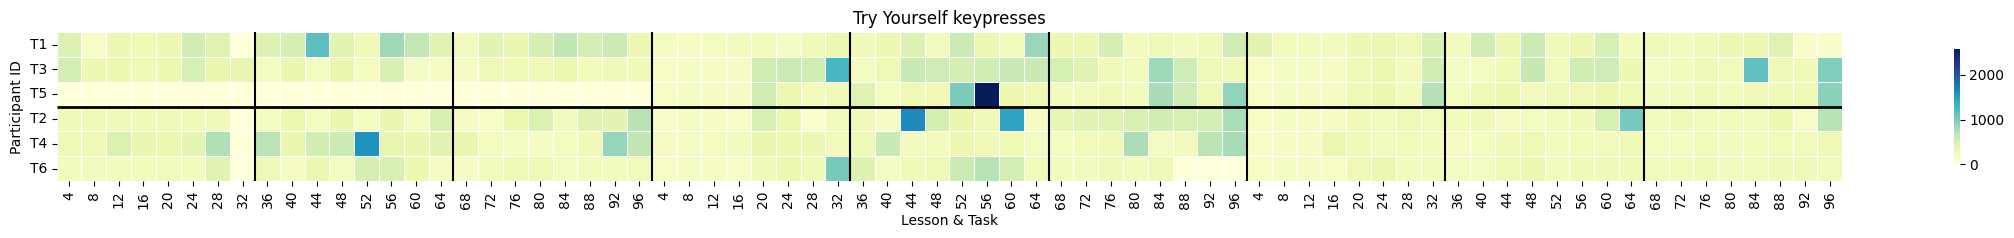

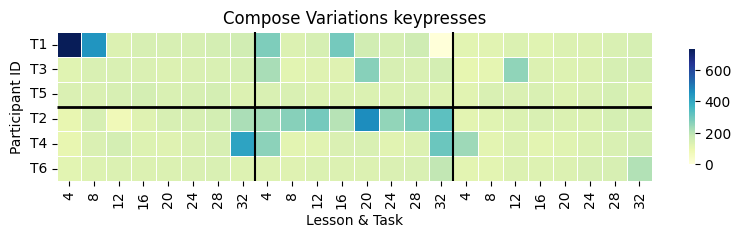

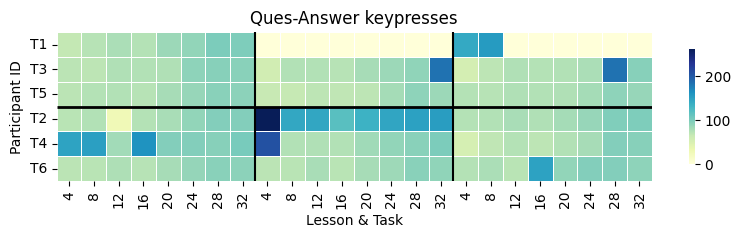

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Create simplified task labels
# Safely extract Day number from strings like 'Day1', 'Day2', etc.
df["DayNum"] = df["Day"].str.extract(r"Day(\d+)")[0].astype(float)
df = df.dropna(subset=["DayNum"])
df["DayNum"] = df["DayNum"].astype(int)
df["Label"] = df.apply(lambda row: f"D{row['DayNum']}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["DayNum", "Lesson", "Task"])

# Pivot the full data: Participant IDs as rows, labels as columns
pivot_full = df.pivot_table(index="ID", columns="Label", values="Keypress_count", aggfunc="sum", fill_value=0)

# Filter participant IDs to those actually present in the pivot table
valid_participants = [p for p in df["ID"].unique() if p in pivot_full.index]
participants = sorted(valid_participants, key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))

# Reindex rows based on AR/Non-AR order
pivot_full = pivot_full.loc[participants]
# Simplify participant IDs
pivot_full.index = [f"T{int(p[1:])}" for p in pivot_full.index]

# Filter columns for subsets based on full ranges
columns_l1_5 = [col for col in pivot_full.columns if re.match(r"D[1-3]L[1-5]T[1-8]?$", col)]
columns_l7 = [col for col in pivot_full.columns if re.match(r"D[2-4]L7T[1-8]$", col)]
columns_l8 = [col for col in pivot_full.columns if re.match(r"D[2-4]L8T[1-8]$", col)]

# Sort columns
columns_l1_5 = sorted(columns_l1_5)
columns_l7 = sorted(columns_l7)
columns_l8 = sorted(columns_l8)

# Subset data
heatmap1 = pivot_full[columns_l1_5]
heatmap2 = pivot_full[columns_l7]
heatmap3 = pivot_full[columns_l8]

# Generate simplified x-axis labels: every 4th tick per day
def generate_numeric_ticks(columns):
    ticks = []
    current_day = None
    tick = 0
    for i, col in enumerate(columns):
        day = col[1]  # 'D1L3T5' → '1'
        if day != current_day:
            current_day = day
            tick = 4
        else:
            tick += 4
        ticks.append(tick)
    return ticks

xticks1 = generate_numeric_ticks(columns_l1_5)
xticks2 = generate_numeric_ticks(columns_l7)
xticks3 = generate_numeric_ticks(columns_l8)

# Helper to find vertical lines for lesson OR day+lesson changes
def get_lesson_boundaries(columns):
    lesson_transitions = []
    last_lesson = ""
    last_day = ""
    for idx, label in enumerate(columns):
        match = re.search(r"D(\d+)L(\d+)T", label)
        if match:
            current_day, current_lesson = match.group(1), match.group(2)
            if current_lesson != last_lesson or current_day != last_day:
                lesson_transitions.append(idx)
                last_lesson = current_lesson
                last_day = current_day
    return lesson_transitions[1:]  # Skip first (start of heatmap)

# Determine split index for AR/Non-AR
split_idx = len(participants) // 2

# Use consistent height across all
figsize1 = (len(heatmap1.columns) * 0.4, len(heatmap1.index) * 0.5)
height_standard = figsize1[1]

# Plot heatmap 1 with custom lines
plt.figure(figsize=(len(heatmap1.columns) * 0.4, height_standard))
ax = sns.heatmap(heatmap1, cmap="YlGnBu", cbar_kws={'shrink': 0.5},
                 xticklabels=xticks1, yticklabels=True, square=True, linewidths=0.5, linecolor='white')

# Add horizontal black line to separate AR and Non-AR participants
ax.hlines(split_idx, *ax.get_xlim(), colors='black', linewidth=2)

# Add vertical lines for lesson and day changes
for col_idx in get_lesson_boundaries(columns_l1_5):
    ax.vlines(col_idx, *ax.get_ylim(), colors='black', linewidth=1.5)

plt.title("Try Yourself keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig("heatmap_lessons1_5.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Plot heatmap 2
plt.figure(figsize=(len(heatmap2.columns) * 0.4, height_standard))
ax = sns.heatmap(heatmap2, cmap="YlGnBu", cbar_kws={'shrink': 0.5},
                 xticklabels=xticks2, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
ax.hlines(split_idx, *ax.get_xlim(), colors='black', linewidth=2)
for col_idx in get_lesson_boundaries(columns_l7):
    ax.vlines(col_idx, *ax.get_ylim(), colors='black', linewidth=1.5)
plt.title("Compose Variations keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig("heatmap_lesson7.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Plot heatmap 3
plt.figure(figsize=(len(heatmap3.columns) * 0.4, height_standard))
ax = sns.heatmap(heatmap3, cmap="YlGnBu", cbar_kws={'shrink': 0.5},
                 xticklabels=xticks3, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
ax.hlines(split_idx, *ax.get_xlim(), colors='black', linewidth=2)
for col_idx in get_lesson_boundaries(columns_l8):
    ax.vlines(col_idx, *ax.get_ylim(), colors='black', linewidth=1.5)
plt.title("Ques-Answer keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig("heatmap_lessons8.pdf", format="pdf", bbox_inches="tight")
plt.show()

now with updated labels lets see

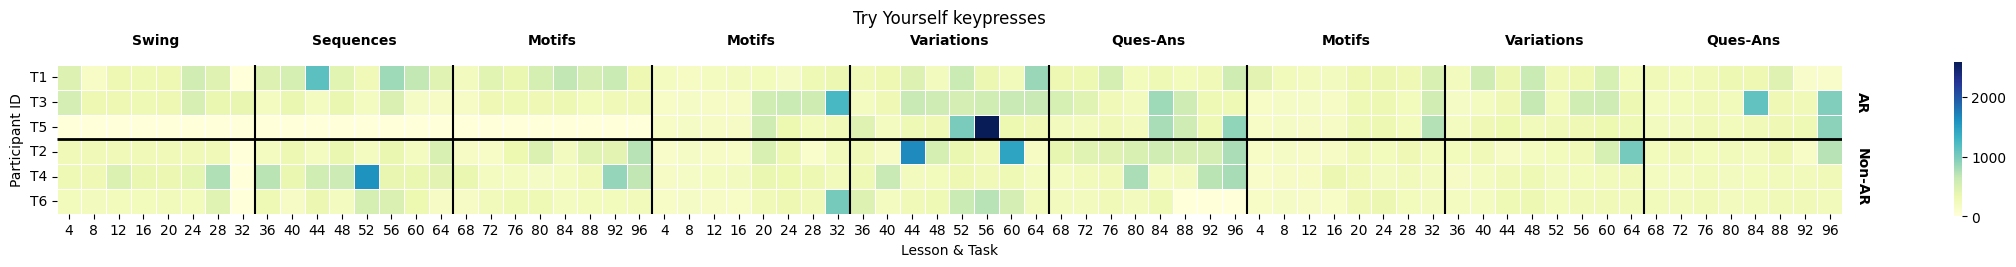

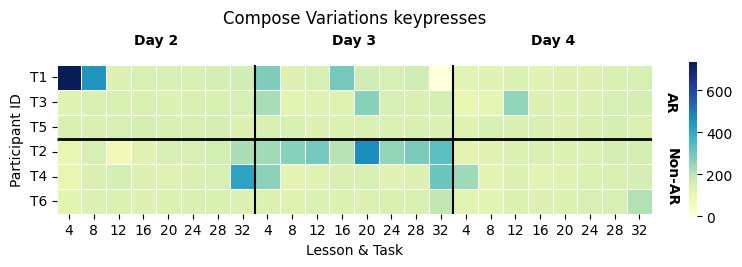

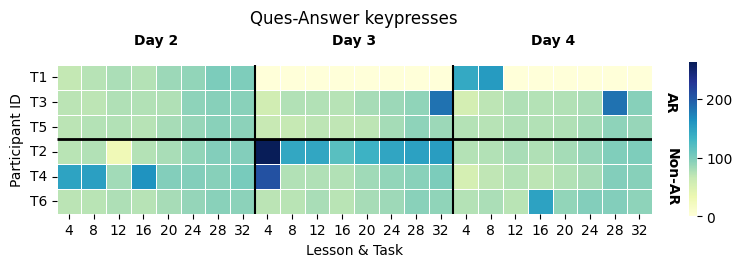

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Create simplified task labels
df["DayNum"] = df["Day"].str.extract(r"Day(\d+)")[0].astype(float)
df = df.dropna(subset=["DayNum"])
df["DayNum"] = df["DayNum"].astype(int)
df["Label"] = df.apply(lambda row: f"D{row['DayNum']}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["DayNum", "Lesson", "Task"])

# Pivot the full data
pivot_full = df.pivot_table(index="ID", columns="Label", values="Keypress_count", aggfunc="sum", fill_value=0)

# Filter and sort participants
valid_participants = [p for p in df["ID"].unique() if p in pivot_full.index]
participants = sorted(valid_participants, key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))
pivot_full = pivot_full.loc[participants]
pivot_full.index = [f"T{int(p[1:])}" for p in pivot_full.index]

# Filter and sort columns
columns_l1_5 = sorted([col for col in pivot_full.columns if re.match(r"D[1-3]L[1-5]T[1-8]?$", col)])
columns_l7 = sorted([col for col in pivot_full.columns if re.match(r"D[2-4]L7T[1-8]$", col)])
columns_l8 = sorted([col for col in pivot_full.columns if re.match(r"D[2-4]L8T[1-8]$", col)])

heatmap1 = pivot_full[columns_l1_5]
heatmap2 = pivot_full[columns_l7]
heatmap3 = pivot_full[columns_l8]

# Tick labels
def generate_numeric_ticks(columns):
    ticks = []
    current_day = None
    tick = 0
    for col in columns:
        day = col[1]
        tick = 4 if day != current_day else tick + 4
        current_day = day
        ticks.append(tick)
    return ticks

xticks1 = generate_numeric_ticks(columns_l1_5)
xticks2 = generate_numeric_ticks(columns_l7)
xticks3 = generate_numeric_ticks(columns_l8)

# Helper to find lesson boundaries
def get_lesson_boundaries(columns):
    transitions = []
    last_day, last_lesson = "", ""
    for idx, label in enumerate(columns):
        match = re.search(r"D(\d+)L(\d+)T", label)
        if match:
            day, lesson = match.group(1), match.group(2)
            if day != last_day or lesson != last_lesson:
                transitions.append(idx)
                last_day, last_lesson = day, lesson
    transitions.append(len(columns))  # Ensure the last segment is captured
    return transitions[1:]

split_idx = len(participants) // 2
figsize1 = (len(heatmap1.columns) * 0.4, len(heatmap1.index) * 0.5)
height_standard = figsize1[1]
top_labels_l1_5 = ["Swing", "Sequences", "Motifs", "Motifs", "Variations", "Ques-Ans", "Motifs", "Variations", "Ques-Ans"]
lesson_bounds_l1_5 = get_lesson_boundaries(columns_l1_5)

plt.figure(figsize=(len(heatmap1.columns) * 0.4, height_standard + 1))
ax = sns.heatmap(heatmap1, cmap="YlGnBu", cbar_kws={'shrink': 0.5},
                 xticklabels=xticks1, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
ax.hlines(split_idx, *ax.get_xlim(), colors='black', linewidth=2)
for col_idx in lesson_bounds_l1_5[:-1]:
    ax.vlines(col_idx, *ax.get_ylim(), colors='black', linewidth=1.5)
ax.text(ax.get_xlim()[1]+0.5, split_idx/2, "AR", va='center', ha='left', rotation=-90, fontsize=10, fontweight='bold')
ax.text(ax.get_xlim()[1]+0.5, split_idx + (len(participants)-split_idx)/2, "Non-AR", va='center', ha='left', rotation=-90, fontsize=10, fontweight='bold')

# Place lesson labels between black lines
for i, label in enumerate(top_labels_l1_5):
    start = lesson_bounds_l1_5[i-1] if i > 0 else 0
    end = lesson_bounds_l1_5[i]
    midpoint = (start + end) / 2
    ax.text(midpoint, -0.7, label, ha='center', va='bottom', rotation=0, fontsize=10, fontweight='bold')

plt.title("Try Yourself keypresses", pad=30)
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.savefig("heatmap_lessons1_5.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Compose heatmaps
for heatmap_data, xticks, lesson_cols, filename, title in [
    (heatmap2, xticks2, columns_l7, "heatmap_lesson7.pdf", "Compose Variations keypresses"),
    (heatmap3, xticks3, columns_l8, "heatmap_lessons8.pdf", "Ques-Answer keypresses")]:

    plt.figure(figsize=(len(heatmap_data.columns) * 0.4, height_standard + 1))
    ax = sns.heatmap(heatmap_data, cmap="YlGnBu", cbar_kws={'shrink': 0.5},
                     xticklabels=xticks, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
    ax.hlines(split_idx, *ax.get_xlim(), colors='black', linewidth=2)
    bounds = get_lesson_boundaries(lesson_cols)
    for col_idx in bounds[:-1]:
        ax.vlines(col_idx, *ax.get_ylim(), colors='black', linewidth=1.5)

    ax.text(ax.get_xlim()[1]+0.5, split_idx/2, "AR", va='center', ha='left', rotation=-90, fontsize=10, fontweight='bold')
    ax.text(ax.get_xlim()[1]+0.5, split_idx + (len(participants)-split_idx)/2, "Non-AR", va='center', ha='left', rotation=-90, fontsize=10, fontweight='bold')

    # Day labels centered between transitions
    day_labels = ["Day 2", "Day 3", "Day 4"]
    for i, label in enumerate(day_labels):
        start = bounds[i-1] if i > 0 else 0
        end = bounds[i] if i < len(bounds) else len(lesson_cols)
        midpoint = (start + end) / 2
        ax.text(midpoint, -0.7, label, ha='center', va='bottom', rotation=0, fontsize=10, fontweight='bold')

    plt.title(title, pad=30)
    plt.xlabel("Lesson & Task")
    plt.ylabel("Participant ID")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()
